In [1]:
%run setting.ipynb

In [2]:
import os
import re
import pandas as pd
import yfinance as yf

In [3]:
# pip install -U scikit-learn

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.express as px

# configuration

In [5]:
leverage_ratio = 2

ETF = "^NDX"
ETF_3x = 'QLD'

# data loading

## QQQ

In [6]:
qqq = yf.Ticker(ETF).history(
    period="max",
    interval="1d",
    auto_adjust=True,   # <-- IMPORTANT
    actions=False
)

In [7]:
qqq

,Open,High,Low,Close,Volume
Date,,,,,
1985-10-01 00:00:00-04:00,110.620003,112.160004,110.565002,112.139999,153160000
1985-10-02 00:00:00-04:00,112.139999,112.540001,110.779999,110.824997,164640000
1985-10-03 00:00:00-04:00,110.839996,111.184998,110.120003,110.870003,147300000
1985-10-04 00:00:00-04:00,110.870003,110.870003,109.855003,110.074997,147900000
1985-10-07 00:00:00-04:00,110.074997,110.135002,108.175003,108.199997,128640000
...,...,...,...,...,...
2026-02-12 00:00:00-05:00,25261.330078,25310.560547,24643.730469,24687.609375,8855290000
2026-02-13 00:00:00-05:00,24662.949219,24921.470703,24514.960938,24732.730469,7964830000
2026-02-17 00:00:00-05:00,24567.539062,24818.300781,24387.470703,24701.599609,7654300000


In [8]:
ETF = ETF.replace('^', '')

qqq =  pd.read_csv(f'^NDX.csv', )

In [9]:
qqq = qqq.reset_index()
qqq['id'] = qqq.index
qqq['Date'] = pd.to_datetime(qqq['Date']).dt.date

In [10]:
qqq.to_sql(
name='qqq', 
con = conn,
if_exists='replace', 
index=False,
)

10175

In [11]:
df = sql(u"""
select * 
from qqq
order by Date asc
""")

In [12]:
qqq

,Date,Open,High,Low,Close,Volume,id
0,1985-10-01,110.620003,112.160004,110.565002,112.139999,153160000,0
1,1985-10-02,112.139999,112.540001,110.779999,110.824997,164640000,1
2,1985-10-03,110.839996,111.184998,110.120003,110.870003,147300000,2
3,1985-10-04,110.870003,110.870003,109.855003,110.074997,147900000,3
4,1985-10-07,110.074997,110.135002,108.175003,108.199997,128640000,4
...,...,...,...,...,...,...,...
10170,2026-02-12,25261.330078,25310.560547,24643.730469,24687.609375,8855290000,10170
10171,2026-02-13,24662.949219,24921.470703,24514.960938,24732.730469,7964830000,10171
10172,2026-02-17,24567.539062,24818.300781,24387.470703,24701.599609,7654300000,10172
10173,2026-02-18,24744.880859,25057.210938,24696.830078,24898.869141,7705590000,10173


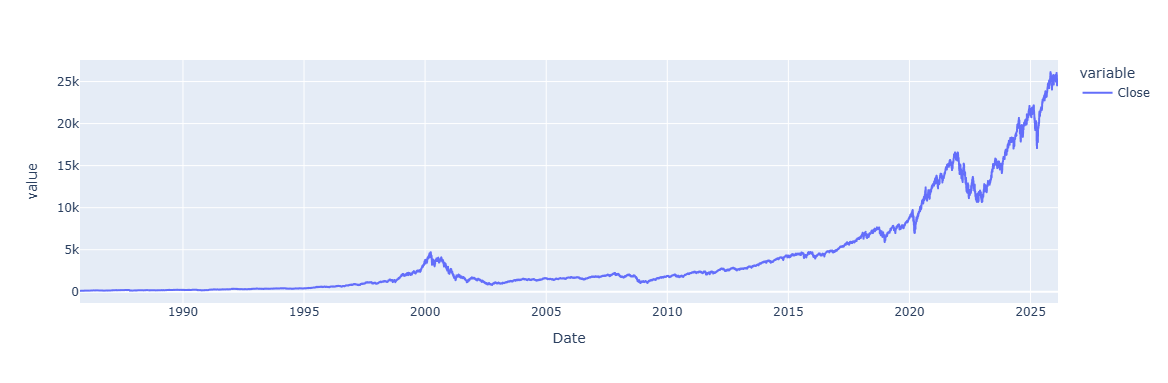

In [13]:
fig = px.line(df, x='Date', y=["Close"])
fig.show()

## QLD

In [14]:
data_3x = yf.Ticker(ETF_3x).history(
    period="max",
    interval="1d",
    auto_adjust=True,   # <-- IMPORTANT
    actions=False
)

data_3x =  pd.read_csv(f'QLD.csv', )

In [15]:
data_3x = data_3x.reset_index()
data_3x['id'] = data_3x.index
data_3x['Date'] = pd.to_datetime(data_3x['Date']).dt.date

In [16]:
data_3x.to_sql(
name='qld', 
con = conn,
if_exists='replace', 
index=False,
)

4947

In [17]:
df = sql(u"""
select * 
from qld
order by Date asc
""")

fig = px.line(df, x='Date', y=["Close"])
fig.show()

# daily percentage of QQQ

In [18]:
sql_to_table(
f"""
select qqq.*, 
pre_day.Date as pre_Date,
pre_day.Close as pre_Close,
(qqq.Close - pre_day.Close)/pre_day.Close AS Percent    
from qqq 
left join qqq as pre_day on pre_day.id+1 = qqq.id
order by qqq.Date asc
""",
'qqq'
)

10175

In [19]:
sql(u"""
select * 
from qqq
order by Date asc
limit 2
""")

,Date,Open,High,Low,Close,Volume,id,pre_Date,pre_Close,Percent
0,1985-10-01,110.620003,112.160004,110.565002,112.139999,153160000,0,None,NaN,NaN
1,1985-10-02,112.139999,112.540001,110.779999,110.824997,164640000,1,1985-10-01,112.139999,-0.011726


In [20]:
sql(u"""
select * 
from qqq
order by Date desc
limit 2
""")

,Date,Open,High,Low,Close,Volume,id,pre_Date,pre_Close,Percent
0,2026-02-19,24771.652344,24890.117188,24690.869141,24797.339844,1031364000,10174,2026-02-18,24898.869141,-0.004078
1,2026-02-18,24744.880859,25057.210938,24696.830078,24898.869141,7705590000,10173,2026-02-17,24701.599609,0.007986


# simulation of daily leverage

In [21]:
data_list = sql(f"""
select 
Date,
Percent, 
{leverage_ratio}*Percent as Leveraged_Percent
from qqq
where Percent is not null
order by Date asc
""".format(leverage_ratio)).to_dict('records')

In [22]:
data_list[0:3]

[{'Date': '1985-10-02',
  'Percent': -0.011726435246687159,
  'Leveraged_Percent': -0.023452870493374318},
 {'Date': '1985-10-03',
  'Percent': 0.0004060978983005295,
  'Leveraged_Percent': 0.000812195796601059},
 {'Date': '1985-10-04',
  'Percent': -0.0071706122363594214,
  'Leveraged_Percent': -0.014341224472718843}]

In [23]:
start_price = qqq['Close'][0]

qqq_price = start_price
tqqq_price = start_price

for r in data_list:
    ###
    qqq_price = qqq_price*(1+r['Percent'])
    r['price'] = qqq_price
    ###
    tqqq_price = tqqq_price*(1+r['Leveraged_Percent'])    
    r['Leveraged_price'] = tqqq_price  

data1 = pd.DataFrame(data_list)

In [24]:
data1.to_sql(
name='leveraged', 
con = conn,
if_exists='replace', 
index=False,
)

10174

In [25]:
df = sql(u"""
select * 
from leveraged
order by Date asc
""")

fig = px.line(df, 
    x='Date', 
    y=[
    'price', 
    'Leveraged_price',
    ])
fig.show()

# regression

In [26]:
compare_3x = sql(u"""
select 
qld.Date,
leveraged.`Leveraged_price`,
qld.Close
from qld
join leveraged on leveraged.Date = qld.Date
order by qld.Date asc
""")

compare_3x.to_sql(
name='compare_3x', 
con = conn,
if_exists='replace', 
index=False,
)

4947

In [27]:
X = compare_3x['Leveraged_price'].to_numpy()
X = np.array([[i] for i in X])
y = compare_3x['Close'].to_numpy()

In [28]:
reg = LinearRegression().fit(X, y)

In [29]:
reg.score(X, y)

print(reg.coef_)

print(reg.intercept_)

[0.00019749]
0.8863481870778909


In [30]:
result = sql(f"""
select 
Date,
`Leveraged_price` * {reg.coef_[0]} + {reg.intercept_} AS simulated_Close,
Close
from compare_3x
""")

result.plot(x ='Date', y=[
    'simulated_Close', 
    'Close',
    ], grid = True)

In [31]:
fig = px.line(result, x='Date', y=["simulated_Close",'Close'])
fig.show()

# all simulation results

In [32]:
final_result = sql(f"""
select 
data1.Date,
data1.price AS {ETF},
data1.`Leveraged_price` * {reg.coef_[0]} + {reg.intercept_} AS simulated_{ETF_3x},
data_3x.Close as {ETF_3x}
from leveraged as data1
left join qld as data_3x 
on data_3x.Date = data1.Date
""")

In [33]:
fig = px.line(
final_result, x='Date', y=[
f'simulated_{ETF_3x}',
ETF_3x])
fig.show()

final_result.plot(x ='Date', y=[
    'simulated_{}'.format(ETF_3x),
    ETF_3x,
    ], grid = True)

In [34]:
final_result.to_excel(
f'{ETF_3x}_simulation.xlsx',
index = False,
)

In [35]:
print(f'{ETF_3x}_simulation.xlsx')

QLD_simulation.xlsx


# simulated qld

In [36]:
df = sql(f"""
select Date, Leveraged_price
from leveraged
order by Date
""")

fig = px.line(
df, x='Date', y=['Leveraged_price'])
fig.show()

In [37]:
sql(f"""
select * 
from leveraged
limit 3
""")

,Date,Percent,Leveraged_Percent,price,Leveraged_price
0,1985-10-02,-0.011726,-0.023453,110.824997,109.509995
1,1985-10-03,0.000406,0.000812,110.870003,109.598938
2,1985-10-04,-0.007171,-0.014341,110.074997,108.027155


# retio of holding x years

In [38]:
def calculate_ratio(
    year = 1,
):

    df = sql(f"""
    with 

    a as (
    select a.Date as before_date, 
    b.Date as after_date,
    a.Leveraged_price as before_price_leveraged,
    b.Leveraged_price as after_price_leverage,
    a.price as before_price,
    b.price as after_price
    from leveraged as a 
    join leveraged as b
    on 
    Cast ((
        JulianDay(b.Date) - JulianDay(a.Date)
    ) As Integer) = {year} * 365
    )

    select before_date,
    after_date, 
    after_price/before_price as price_ratio,
    after_price_leverage/before_price_leveraged as price_ratio_leverage
    from a 
    """)

    df.to_sql(
    name='price_ratio', 
    con = conn,
    if_exists='replace', 
    index=False,
    )

    return {
        'holding_years':year,
        'qqq_return': sql(f"""
            select price_ratio
            from price_ratio
            """).median()[0] - 1, 
        'qld_return': sql(f"""
            select price_ratio_leverage
            from price_ratio
            """).median()[0] - 1
    }

In [39]:
%%time

output = []

for year in [1, 2, 3, 5, 10, 15, 20, 25, 30]:
    output.append(calculate_ratio(year = year))

C:\Users\yanli\AppData\Local\Temp\ipykernel_29924\1334120834.py:39: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\yanli\AppData\Local\Temp\ipykernel_29924\1334120834.py:43: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\yanli\AppData\Local\Temp\ipykernel_29924\1334120834.py:39: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\yanli\AppData\Local\Temp\ipykernel_29924\1334120834.py:43: FutureWarning:

Series.__g

CPU times: total: 4min 28s
Wall time: 4min 34s


In [40]:
return_df = pd.DataFrame(output)

In [41]:
return_df

,holding_years,qqq_return,qld_return
0,1,0.173244,0.324094
1,2,0.313929,0.598034
2,3,0.521151,1.077216
3,5,1.028972,2.280902
4,10,2.715291,4.700541
5,15,4.849408,9.463592
6,20,7.834290,12.381674
7,25,16.183346,40.272855
8,30,39.285880,179.620655


In [42]:
return_df.to_excel(f'qqq_qld_return.xlsx', index = False)

# check the ration by all windows

In [43]:
sql(f"""
select *
from price_ratio
""")

,before_date,after_date,price_ratio,price_ratio_leverage
0,1985-10-02,2015-09-25,38.120824,161.763762
1,1985-10-07,2015-09-30,38.641961,166.035519
2,1985-10-08,2015-10-01,39.128031,170.253516
3,1985-10-09,2015-10-02,39.284270,171.595017
4,1985-10-14,2015-10-07,38.286523,163.043466
...,...,...,...,...
1535,1996-02-14,2026-02-06,40.602614,169.620120
1536,1996-02-20,2026-02-12,40.023359,164.733148
1537,1996-02-21,2026-02-13,39.428532,159.916852
1538,1996-02-26,2026-02-18,39.031336,156.808254


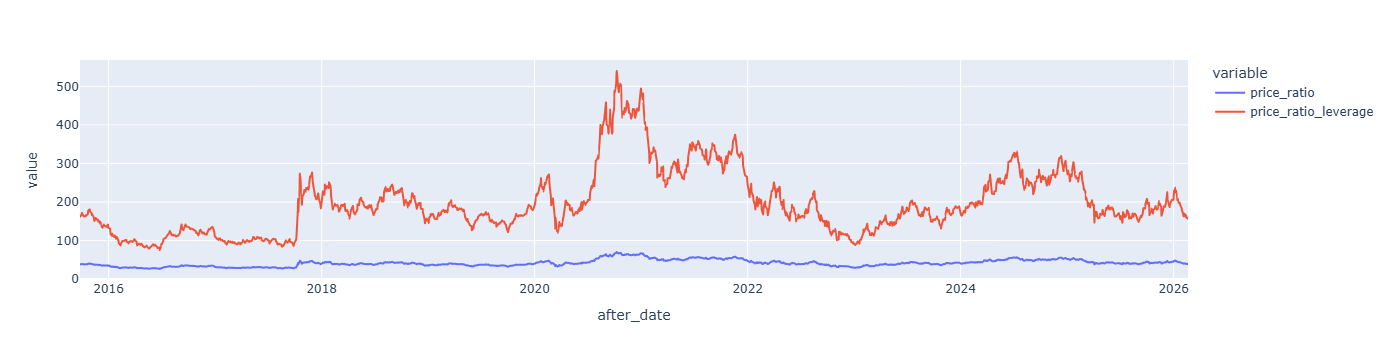

In [44]:
df = sql(f"""
select * 
from price_ratio
""")

fig = px.line(
df, x='after_date', y=['price_ratio', 'price_ratio_leverage'])
fig.show()

# END